# FHFA House Price Index: Real Estate Investment Data Exploration

**Author:** Ozzie Shenk

## 1. Understanding the Data


In [22]:
import pandas as pd

csv_url = "https://www.fhfa.gov/hpi/download/monthly/hpi_master.csv"

df = pd.read_csv(csv_url)

df.head()

/tmp/ipykernel_468/500998676.py:5: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_url)


,hpi_type,hpi_flavor,frequency,level,place_name,place_id,yr,period,index_nsa,index_sa,rstderr,note
0,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,1,100.00,100.00,NaN,NaN
1,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,2,100.87,100.87,NaN,NaN
2,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,3,101.32,100.90,NaN,NaN
3,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,4,101.73,100.96,NaN,NaN
4,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,5,102.32,101.31,NaN,NaN


In [23]:
print("Rows and columns:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Rows and columns: (186011, 12)

Column names:
['hpi_type', 'hpi_flavor', 'frequency', 'level', 'place_name', 'place_id', 'yr', 'period', 'index_nsa', 'index_sa', 'rstderr', 'note']

Data types:
hpi_type       object
hpi_flavor     object
frequency      object
level          object
place_name     object
place_id       object
yr              int64
period          int64
index_nsa     float64
index_sa      float64
rstderr       float64
note           object
dtype: object


In [24]:
print("Earliest year:", df['yr'].min())
print("Latest year:", df['yr'].max())

print("\nFrequencies:")
print(df['frequency'].value_counts())

print("\nGeographic levels:")
print(df['level'].value_counts())

print("\nNumber of unique places:", df['place_name'].nunique())

Earliest year: 1975
Latest year: 2026

Frequencies:
frequency
quarterly    181751
monthly        4260
Name: count, dtype: int64

Geographic levels:
level
MSA                       145480
State                      30912
USA or Census Division      9372
Puerto Rico                  247
Name: count, dtype: int64

Number of unique places: 472


### When and Where Was the Data Acquired?

The dataset was obtained from the Federal Housing Finance Agency (FHFA) House Price Index and was accessed on September 23, 2026. The Master HPI dataset contains observations ranging from 1975 through 2026, although the available time period varies depending on the specific HPI series.

The dataset covers several geographic levels across the United States. These include states, Metropolitan Statistical Areas (MSAs), U.S. Census Divisions, the United States as a whole, and Puerto Rico. The dataset contains 472 unique geographic place names.

### How Was the Data Acquired?

The FHFA House Price Index is created from housing transaction and mortgage data. One major series in the dataset is the Purchase-Only HPI, which uses sales price information from mortgages purchased or securitized by Fannie Mae and Freddie Mac. FHFA applies a weighted repeat-sales method that compares the prices of the same properties when they are sold more than once over time.

The Master HPI dataset also combines multiple HPI versions, or "flavors," so the exact data sources can differ depending on the series. This is important because the dataset does not represent one single type of housing-price observation.

### Dataset Attributes

The Master HPI dataset contains 12 attributes. Although some attributes are stored numerically in Python, the appropriate statistical treatment depends on what the variable represents.

| Attribute | Description | Data Type |
|---|---|---|
| hpi_type | Type of House Price Index being reported | Categorical - Nominal |
| hpi_flavor | Version or methodology of the HPI | Categorical - Nominal |
| frequency | Reporting frequency, such as monthly or quarterly | Categorical - Nominal |
| level | Geographic level of the observation | Categorical - Nominal |
| place_name | Name of the geographic area | Categorical - Nominal |
| place_id | Identifier for the geographic area | Categorical Identifier |
| yr | Calendar year of the observation | Temporal / Interval |
| period | Month or quarter within the year | Ordered Temporal |
| index_nsa | House Price Index, not seasonally adjusted | Quantitative / Continuous |
| index_sa | Seasonally adjusted House Price Index | Quantitative / Continuous |
| rstderr | Relative standard error of the estimate | Quantitative / Continuous |
| note | Additional information associated with an observation | Text |


## 2. Data Summary & Initial Insights

### Summary Statistics

Because the dataset contains categorical, temporal, and numerical variables, different summary measures are appropriate for different attributes.


In [25]:
# Categorical and time variables
categorical_time_summary = pd.DataFrame({
    'Unique Values': [
        df['hpi_type'].nunique(),
        df['hpi_flavor'].nunique(),
        df['frequency'].nunique(),
        df['level'].nunique(),
        df['place_name'].nunique(),
        df['place_id'].nunique(),
        df['yr'].nunique(),
        df['period'].nunique()
    ],
    'Most Common / Range': [
        df['hpi_type'].mode()[0],
        df['hpi_flavor'].mode()[0],
        df['frequency'].mode()[0],
        df['level'].mode()[0],
        df['place_name'].mode()[0],
        'Identifier',
        f"{df['yr'].min()} to {df['yr'].max()}",
        "1-12 monthly / 1-4 quarterly"
    ]
}, index=[
    'hpi_type',
    'hpi_flavor',
    'frequency',
    'level',
    'place_name',
    'place_id',
    'yr',
    'period'
])

categorical_time_summary

,Unique Values,Most Common / Range
hpi_type,5,traditional
hpi_flavor,3,all-transactions
frequency,2,quarterly
level,4,MSA
place_name,472,United States
place_id,472,Identifier
yr,52,1975 to 2026
period,12,1-12 monthly / 1-4 quarterly


#### Numerical Variables

In [26]:
# Numerical variables
numeric_cols = ['index_nsa', 'index_sa', 'rstderr']

numerical_summary = pd.DataFrame({
    'Mean': df[numeric_cols].mean(),
    'Median': df[numeric_cols].median(),
    'Mode': df[numeric_cols].mode().iloc[0],
    'Minimum': df[numeric_cols].min(),
    'Maximum': df[numeric_cols].max(),
    'Range': df[numeric_cols].max() - df[numeric_cols].min(),
    'Standard Deviation': df[numeric_cols].std()
})

numerical_summary.round(2)

,Mean,Median,Mode,Minimum,Maximum,Range,Standard Deviation
index_nsa,199.96,172.13,100.0,18.60,1326.94,1308.34,116.13
index_sa,216.67,187.21,100.0,72.78,1043.20,970.42,113.51
rstderr,2.67,2.05,0.0,0.00,15.75,15.75,2.22


### Initial Observations

The summary statistics show that the Master HPI dataset contains several different types of housing price indexes, geographic levels, and reporting frequencies. Most observations are quarterly, and the largest geographic category is Metropolitan Statistical Areas (MSAs). The dataset covers 472 unique geographic areas and observations ranging from 1975 through 2026.

For the numerical variables, the non-seasonally adjusted HPI (`index_nsa`) ranges from 18.60 to 1326.94, while the seasonally adjusted HPI (`index_sa`) ranges from 72.78 to 1043.20. These broad ranges reflect the fact that the Master dataset combines many different HPI series, locations, and time periods. Therefore, the overall means and medians are useful for describing the dataset, but they should not be interpreted as the average level of U.S. home prices.

To analyze housing-market trends more directly, it is more appropriate to examine a consistent HPI series over time, such as the national traditional purchase-only series used in the visualization below.

In [27]:
missing_summary = pd.DataFrame({
    'Missing Values': df.isna().sum(),
    'Percent Missing': (df.isna().sum() / len(df) * 100).round(2)
})

missing_summary

,Missing Values,Percent Missing
hpi_type,0,0.00
hpi_flavor,0,0.00
frequency,0,0.00
level,0,0.00
place_name,0,0.00
place_id,0,0.00
yr,0,0.00
period,0,0.00
index_nsa,0,0.00
index_sa,89897,48.33


### Missing Values

Most variables in the dataset have no missing observations. However, `index_sa` has 89,897 missing values, representing 48.33% of the dataset. The `rstderr` and `note` variables each have 127,791 missing observations, or 68.70%.

Because such a large portion of these variables is missing, automatically deleting every row containing a missing value would remove a significant amount of data. A better approach would depend on the specific analysis being performed. For example, an analysis using `index_nsa` would not require removing observations simply because `index_sa` or `rstderr` is missing. Before imputing or deleting values, I would also investigate whether the missing observations are related to particular HPI series, geographic levels, or reporting frequencies.

In [28]:
# See which U.S. HPI series are available
usa = df[df['place_name'] == 'United States']

usa[['hpi_type', 'hpi_flavor', 'frequency']].drop_duplicates()

,hpi_type,hpi_flavor,frequency
3834,traditional,purchase-only,monthly
87692,traditional,all-transactions,quarterly
154638,traditional,expanded-data,quarterly
177500,traditional,purchase-only,quarterly
183564,manufactured,all-transactions,quarterly
183670,manufactured,purchase-only,quarterly


### U.S. House Price Index Over Time


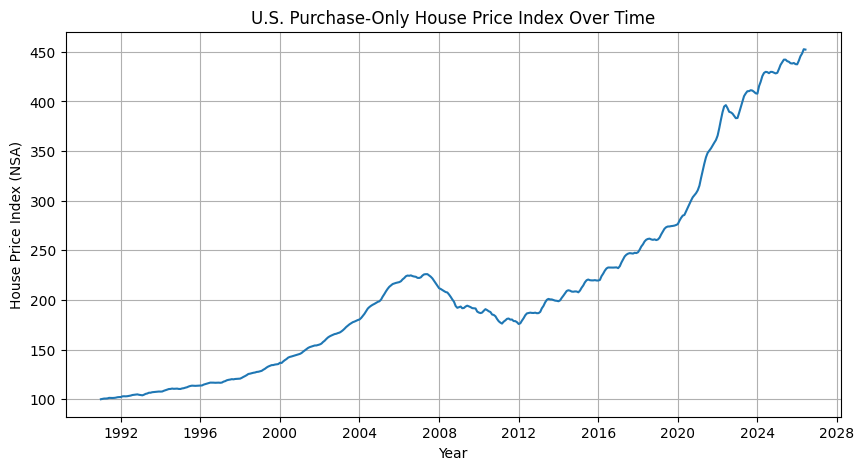

In [29]:
import matplotlib.pyplot as plt

# Select one consistent national HPI series
usa_monthly = df[
    (df['place_name'] == 'United States') &
    (df['hpi_type'] == 'traditional') &
    (df['hpi_flavor'] == 'purchase-only') &
    (df['frequency'] == 'monthly')
].copy()

# Create a date from the year and month columns
usa_monthly['date'] = pd.to_datetime(
    dict(year=usa_monthly['yr'], month=usa_monthly['period'], day=1)
)

usa_monthly = usa_monthly.sort_values('date')

# Plot the House Price Index
plt.figure(figsize=(10, 5))
plt.plot(usa_monthly['date'], usa_monthly['index_nsa'])

plt.title('U.S. Purchase-Only House Price Index Over Time')
plt.xlabel('Year')
plt.ylabel('House Price Index (NSA)')
plt.grid(True)
plt.show()

### Visualization Findings

The U.S. Purchase-Only House Price Index shows a clear long-term upward trend. The index increased steadily through the 1990s and early 2000s, declined following the mid-2000s housing-market peak, and began increasing again during the early 2010s. The rise becomes particularly steep after 2020.

From an investment perspective, this demonstrates both the long-term growth in U.S. residential property values and the fact that housing markets can experience meaningful declines. Looking at one consistent HPI series over time provides a clearer picture of market trends than comparing index values across all of the different series contained in the Master dataset.


## 3. Expanding My Investment Knowledge

### Additional Dataset: American Community Survey (ACS)

An additional dataset that would be useful for real estate investment analysis is the U.S. Census Bureau's American Community Survey (ACS). The ACS provides information about population, household income, employment, housing characteristics, and other economic and demographic factors across different geographic areas.

This dataset would complement the FHFA House Price Index because the two datasets measure different parts of the housing market. The FHFA data mainly shows how home prices change over time, while the ACS provides information about the people and communities behind those price changes. For example, I could compare an area's home price growth with its population growth, household income, employment, or housing characteristics.

Using the two datasets together could provide a more complete view of a potential real estate investment. Instead of only seeing that home prices are rising or falling, I could also examine economic and demographic factors that may help explain those trends.

**Dataset:** U.S. Census Bureau American Community Survey (ACS)  
**Link:** https://www.census.gov/programs-surveys/acs/data.html

## 4. Conclusion

The FHFA House Price Index provides a useful way to see how U.S. home values have changed over time and across different geographic areas. The data shows a strong long-term increase in home prices, although there have also been periods of decline, including the housing-market downturn around the 2008 financial crisis.

For someone considering a real estate investment, the HPI is helpful for identifying long-term price trends, but it should not be used by itself. Combining FHFA price data with economic and demographic information from a source such as the American Community Survey could provide a more complete picture of a market before making an investment decision.